In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('Bengaluru_House_Data.csv')
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew,kurtosis
import sympy as sp

<Axes: ylabel='price'>

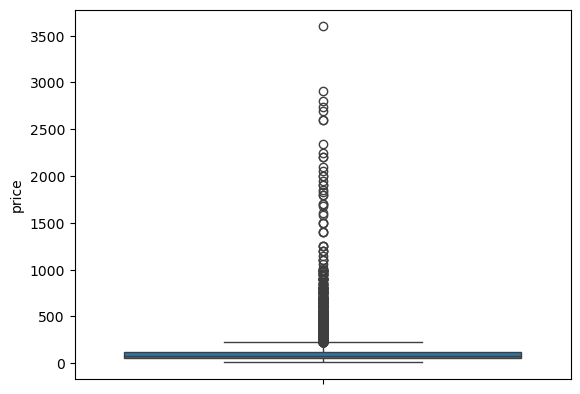

In [6]:
sns.boxplot(df['price'])

<Axes: ylabel='price'>

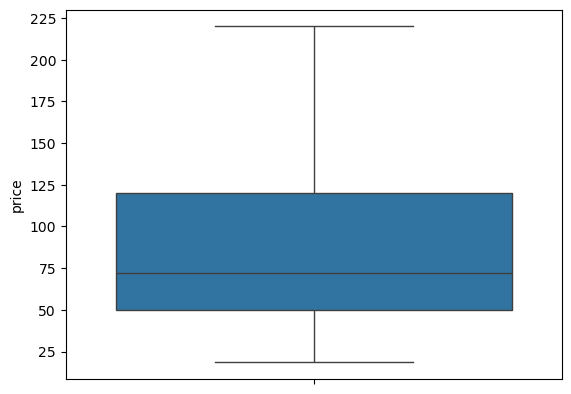

In [10]:
## percentile method

ll=np.percentile(df['price'],1)
ul=np.percentile(df['price'],90)
a=df['price'].clip(lower=ll,upper=ul)
sns.boxplot(a)

<Axes: ylabel='price'>

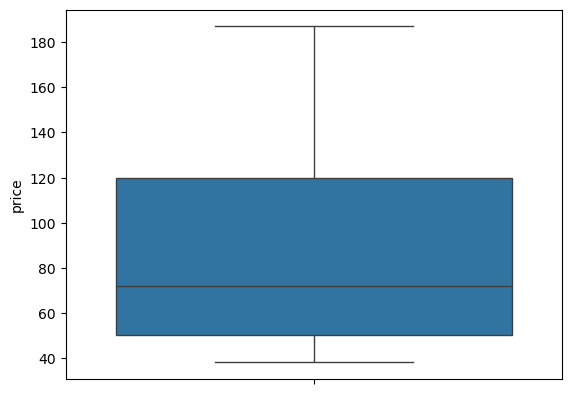

In [11]:
### z method

u=np.mean(df['price'])
std=np.std(df['price'])

ll=u-(.5*std)
ul=u+(.5*std)

sns.boxplot(df['price'].clip(lower=ll,upper=ul))

In [14]:
df.shape

(13320, 9)

In [15]:
df.size

119880

In [16]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [17]:
df['bath'].unique

<bound method Series.unique of 0        2.0
1        5.0
2        2.0
3        3.0
4        2.0
        ... 
13315    4.0
13316    5.0
13317    2.0
13318    4.0
13319    1.0
Name: bath, Length: 13320, dtype: float64>

In [18]:
df['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr', '16-Jan', '14-Jul'], dtype=object)

In [19]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [20]:
df['location'].value_counts()

location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [21]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [22]:
df['society'].unique()

array(['Coomee ', 'Theanmp', nan, ..., 'SJovest', 'ThhtsV ', 'RSntsAp'],
      dtype=object)

In [14]:
#1 Display all rows where the price is greater than 1 crore.

df[df['price']>100]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.0
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.0
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.0
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.0
...,...,...,...,...,...,...,...,...,...
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7 Bedroom,NaN,1500,9.0,2.0,250.0
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.0
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0


In [15]:
#2 Retrieve all properties located in the area “Whitefield”.

df[df['location']=='Whitefield']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
10,Super built-up Area,18-Feb,Whitefield,3 BHK,NaN,1800,2.0,2.0,70.00
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.00
27,Built-up Area,20-Dec,Whitefield,3 BHK,NaN,1610,3.0,2.0,81.00
47,Super built-up Area,20-Sep,Whitefield,2 BHK,Goted U,1459,2.0,1.0,94.82
...,...,...,...,...,...,...,...,...,...
13235,Super built-up Area,Ready To Move,Whitefield,3 BHK,SJces R,1730,3.0,2.0,125.00
13257,Super built-up Area,Ready To Move,Whitefield,3 BHK,SLiritn,1453,2.0,2.0,58.00
13258,Super built-up Area,19-Dec,Whitefield,1 BHK,Oreldhi,877,1.0,1.0,59.00
13299,Super built-up Area,18-Dec,Whitefield,4 BHK,Prtates,2830 - 2882,5.0,0.0,154.50


In [16]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [17]:
#3 Show houses that have more than 3 bedrooms.

#df[size]=df['size'].str.extract(r'(\d+)').astype('Int64')
df['size']=df['size'].str.split(' ').str[0].astype('Int64')   ## its alredy done and deleted


df[df['size']>3]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600,5.0,3.0,120.0
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732,4.0,NaN,204.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,Brway G,3300,4.0,NaN,600.0
9,Plot Area,Ready To Move,Gandhi Bazar,6,NaN,1020,6.0,NaN,370.0
11,Plot Area,Ready To Move,Whitefield,4,Prrry M,2785,5.0,3.0,295.0
...,...,...,...,...,...,...,...,...,...
13306,Plot Area,Ready To Move,Rajarajeshwari Nagara,4,NaN,1200,5.0,NaN,325.0
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7,NaN,1500,9.0,2.0,250.0
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600,5.0,NaN,400.0


In [18]:
#4 Select rows where bath is greater than balcony.

df[df['bath']>df['balcony']]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600,5.0,3.0,120.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170,2.0,1.0,38.00
...,...,...,...,...,...,...,...,...,...
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7,NaN,1500,9.0,2.0,250.00
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345,2.0,1.0,57.00
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453,4.0,0.0,231.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141,2.0,1.0,60.00


In [19]:
def foo1(x):
    if isinstance(x, str):
        if '-' in x:
            parts = x.split('-')
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        try:
            return float(x.strip())
        except ValueError:
            return None
    return x

In [20]:
#5 Display all houses with total square feet greater than 2000.

def foo(x):
    a=float(x)
    if '-' in x:
        a=x.split('-')
        return (float(a[0].strip())+float(a[1].strip()))/2



df['total_sqft']=df['total_sqft'].apply(foo1)
## its already done
df[df['total_sqft']>2000]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.0
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,Brway G,3300.0,4.0,NaN,600.0
11,Plot Area,Ready To Move,Whitefield,4,Prrry M,2785.0,5.0,3.0,295.0
14,Plot Area,Ready To Move,Sarjapur,3,Skityer,2250.0,3.0,2.0,148.0
...,...,...,...,...,...,...,...,...,...
13294,Super built-up Area,Ready To Move,Sultan Palaya,4,RSntsAp,2200.0,3.0,3.0,80.0
13299,Super built-up Area,18-Dec,Whitefield,4,Prtates,2856.0,5.0,0.0,154.5
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.0


In [21]:
#5 Get all properties with more than 2 bathrooms and located in “Electronic City”.

df[df['location']=='Electronic City'][df['bath']>2]

C:\Users\AKASH\AppData\Local\Temp\ipykernel_1684\363097385.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['location']=='Electronic City'][df['bath']>2]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
245,Plot Area,Ready To Move,Electronic City,3,NaN,1200.0,3.0,1.0,90.00
378,Super built-up Area,Ready To Move,Electronic City,3,ShstaAl,1800.0,3.0,2.0,95.00
522,Super built-up Area,18-Apr,Electronic City,3,Prarkun,1599.0,3.0,2.0,125.00
543,Super built-up Area,18-Apr,Electronic City,3,Prarkun,1599.0,3.0,2.0,99.00
1191,Built-up Area,Ready To Move,Electronic City,3,Suashen,1620.0,3.0,2.0,62.00
1325,Plot Area,Ready To Move,Electronic City,4,NaN,2000.0,4.0,0.0,120.00
2089,Super built-up Area,18-Jan,Electronic City,3,Prarkun,1571.0,3.0,2.0,89.00
2111,Super built-up Area,18-Dec,Electronic City,3,NaN,1111.0,3.0,1.0,50.00
3020,Plot Area,18-Dec,Electronic City,4,Janaala,4000.0,5.0,1.0,150.00
3131,Super built-up Area,21-Dec,Electronic City,3,KonteiT,1563.0,3.0,2.0,91.84


In [22]:
#6 Retrieve all listings whose location contains “Indiranagar”.

df[df['location']=='indiranagar']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price


In [23]:
#7 Filter properties where price_per_sqft is between 4000 and 7000.

df['pps']=df['price']/df['total_sqft']# arlrdy done

df[(df['pps']>0.04)&(df['pps']<0.07)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
8,Super built-up Area,Ready To Move,Marathahalli,3,NaN,1310.0,3.0,1.0,63.25,0.048282
...,...,...,...,...,...,...,...,...,...,...
13310,Super built-up Area,Ready To Move,Rachenahalli,2,NaN,1050.0,2.0,2.0,52.71,0.050200
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345.0,2.0,1.0,57.00,0.042379
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.00,0.065306
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898


In [24]:
df.sample()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
11690,Built-up Area,Ready To Move,Kashi Nagar,2,Adarkya,1190.0,2.0,2.0,42.0,0.035294


In [25]:
#8 Show all rows where availability equals “Ready To Move”.

df[df['availability']=='Ready To Move']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.0,0.046154
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.0,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.0,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.0,0.042500
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170.0,2.0,1.0,38.0,0.032479
...,...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.0,0.065306
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.0,0.066898
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.0,0.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.0,0.052585


In [26]:
#9 Get listings that are available “Immediately”.

df[df['availability']=='Immediate Possession']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
579,Plot Area,Immediate Possession,Sarjapur Road,<NA>,Asiss B,1800.0,NaN,NaN,34.185,0.018992
1775,Plot Area,Immediate Possession,IVC Road,<NA>,Orana N,3817.0,NaN,NaN,124.000,0.032486
2264,Plot Area,Immediate Possession,Banashankari,<NA>,NaN,2400.0,NaN,NaN,460.000,0.191667
2809,Plot Area,Immediate Possession,Sarjapur Road,<NA>,AsdiaAr,1800.0,NaN,NaN,28.785,0.015992
2862,Plot Area,Immediate Possession,Devanahalli,<NA>,Ajleyor,1950.0,NaN,NaN,46.800,0.024000
5333,Plot Area,Immediate Possession,Devanahalli,<NA>,Emngs S,3752.5,NaN,NaN,177.115,0.047199
6423,Plot Area,Immediate Possession,Whitefield,<NA>,SRniaGa,2324.0,NaN,NaN,26.730,0.011502
6636,Plot Area,Immediate Possession,Jigani,<NA>,S2enste,1500.0,NaN,NaN,25.490,0.016993
6719,Plot Area,Immediate Possession,Hoskote,<NA>,SJowsn,1730.0,NaN,NaN,28.545,0.016500
7680,Plot Area,Immediate Possession,Kasavanhalli,<NA>,NaN,5000.0,NaN,NaN,400.000,0.080000


In [27]:
#10 Display houses where the size column contains “4 BHK”.

df[df['size']==4]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.0,0.046154
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.0,0.074671
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,Brway G,3300.0,4.0,NaN,600.0,0.181818
11,Plot Area,Ready To Move,Whitefield,4,Prrry M,2785.0,5.0,3.0,295.0,0.105925
22,Plot Area,Ready To Move,Thanisandra,4,Soitya,2800.0,5.0,2.0,380.0,0.135714
...,...,...,...,...,...,...,...,...,...,...
13294,Super built-up Area,Ready To Move,Sultan Palaya,4,RSntsAp,2200.0,3.0,3.0,80.0,0.036364
13299,Super built-up Area,18-Dec,Whitefield,4,Prtates,2856.0,5.0,0.0,154.5,0.054097
13306,Plot Area,Ready To Move,Rajarajeshwari Nagara,4,NaN,1200.0,5.0,NaN,325.0,0.270833
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.0,0.111111


In [28]:
#11 Select properties where balcony equals zero.

df[df['balcony']==0]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
24,Super built-up Area,18-Nov,Thanisandra,1,Bhe 2ko,510.0,1.0,0.0,25.250,0.049510
30,Super built-up Area,19-Dec,Yelahanka,4,LedorSa,2475.0,4.0,0.0,186.000,0.075152
42,Super built-up Area,Ready To Move,Ganga Nagar,1,Ceove G,600.0,1.0,0.0,38.000,0.063333
43,Plot Area,Ready To Move,Yelahanka,1,NaN,660.0,1.0,0.0,48.000,0.072727
46,Super built-up Area,Ready To Move,Doddathoguru,2,LancyRe,970.0,2.0,0.0,33.000,0.034021
...,...,...,...,...,...,...,...,...,...,...
13260,Built-up Area,Ready To Move,Frazer Town,2,Saentpa,1420.0,2.0,0.0,120.000,0.084507
13265,Super built-up Area,20-Sep,Hoodi,2,Ranuetz,1258.5,2.0,0.0,59.135,0.046988
13291,Plot Area,18-Jan,Weavers Colony,1,NaN,812.0,1.0,0.0,26.000,0.032020
13299,Super built-up Area,18-Dec,Whitefield,4,Prtates,2856.0,5.0,0.0,154.500,0.054097


In [29]:
#12 Filter rows where area_type is “Super built-up Area”.

df[df['area_type']=='Super built-up  Area']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170.0,2.0,1.0,38.00,0.032479
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.00,0.074671
...,...,...,...,...,...,...,...,...,...,...
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345.0,2.0,1.0,57.00,0.042379
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.00,0.065306
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073


In [30]:
df['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [31]:
#13 Retrieve all properties where bath > 3 and price< 80.

df[(df['bath']>3)&(df['price']<80)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
222,Built-up Area,Ready To Move,"Lakshminarayanapura, Electronic City Phase 2",4,NaN,2000.0,4.0,1.0,75.5,0.037750
265,Built-up Area,Ready To Move,Attibele,4,Natic T,1600.0,4.0,0.0,52.8,0.033000
308,Super built-up Area,Ready To Move,Begur,4,Prntsrt,1664.0,4.0,3.0,65.0,0.039062
603,Plot Area,Ready To Move,Doddagubbi,3,NaN,1125.0,4.0,1.0,70.0,0.062222
617,Built-up Area,Ready To Move,R.T. Nagar,4,NaN,1500.0,4.0,1.0,70.0,0.046667
...,...,...,...,...,...,...,...,...,...,...
13045,Plot Area,Ready To Move,Vasanthpura,6,NaN,600.0,6.0,2.0,65.0,0.108333
13146,Super built-up Area,Ready To Move,Basavanapura,7,NaN,1800.0,5.0,3.0,65.0,0.036111
13221,Plot Area,Ready To Move,T Dasarahalli,9,NaN,1178.0,9.0,1.0,75.0,0.063667
13275,Plot Area,Ready To Move,Kothannur,4,NaN,1600.0,4.0,2.0,45.0,0.028125


In [32]:
#14 Get listings where total_sqft column value is a number and greater than 1500.

df[df['total_sqft']>1500]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.00,0.074671
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,Brway G,3300.0,4.0,NaN,600.00,0.181818
10,Super built-up Area,18-Feb,Whitefield,3,NaN,1800.0,2.0,2.0,70.00,0.038889
...,...,...,...,...,...,...,...,...,...,...
13309,Super built-up Area,Ready To Move,Yeshwanthpur,3,IBityin,1675.0,3.0,NaN,92.13,0.055003
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.00,0.065306
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111


In [33]:
#15 Display houses in “Marathahalli” with a price_per_sqft > 6000.

df[(df['location']=='Marathahalli')&(df['pps']>0.06)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
322,Plot Area,Ready To Move,Marathahalli,2,NaN,1200.0,2.0,2.0,128.0,0.106667
429,Super built-up Area,Ready To Move,Marathahalli,3,Prionad,1933.0,3.0,2.0,140.0,0.072426
559,Plot Area,Ready To Move,Marathahalli,4,NaN,1780.0,4.0,3.0,175.0,0.098315
576,Super built-up Area,Ready To Move,Marathahalli,2,Aahts H,1230.0,2.0,2.0,80.0,0.065041
634,Super built-up Area,Ready To Move,Marathahalli,4,PueraRi,3800.0,4.0,3.0,250.0,0.065789
...,...,...,...,...,...,...,...,...,...,...
11602,Super built-up Area,Ready To Move,Marathahalli,3,NCenega,1449.0,3.0,2.0,110.0,0.075914
11817,Super built-up Area,Ready To Move,Marathahalli,2,Prionad,1360.0,2.0,1.0,101.0,0.074265
11976,Built-up Area,Ready To Move,Marathahalli,2,Aantspa,1270.0,2.0,2.0,80.0,0.062992
12968,Built-up Area,Ready To Move,Marathahalli,3,NaN,1485.0,2.0,2.0,90.0,0.060606


In [34]:
#16 Retrieve all properties with 2 BHK or 3 BHK only.

df[(df['size']==2)|(df['size']==3)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170.0,2.0,1.0,38.00,0.032479
...,...,...,...,...,...,...,...,...,...,...
13310,Super built-up Area,Ready To Move,Rachenahalli,2,NaN,1050.0,2.0,2.0,52.71,0.050200
13312,Super built-up Area,Ready To Move,Bellandur,2,NaN,1262.0,2.0,2.0,47.00,0.037242
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345.0,2.0,1.0,57.00,0.042379
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.00,0.065306


In [35]:
#17 Filter houses with an even number of bathrooms.

df[df['bath']%2==0]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170.0,2.0,1.0,38.00,0.032479
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.00,0.074671
...,...,...,...,...,...,...,...,...,...,...
13312,Super built-up Area,Ready To Move,Bellandur,2,NaN,1262.0,2.0,2.0,47.00,0.037242
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345.0,2.0,1.0,57.00,0.042379
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585


In [36]:
#18 Display listings where the number of bathrooms is less than bedrooms.

df[(df['size'])>(df['bath'])]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
10,Super built-up Area,18-Feb,Whitefield,3,NaN,1800.0,2.0,2.0,70.00,0.038889
26,Super built-up Area,Ready To Move,Electronic City,2,Itelaa,660.0,1.0,1.0,23.10,0.035000
29,Super built-up Area,Ready To Move,Electronic City,3,KBityo,1025.0,2.0,1.0,47.00,0.045854
31,Super built-up Area,Ready To Move,Bisuvanahalli,3,Prityel,1075.0,2.0,1.0,35.00,0.032558
...,...,...,...,...,...,...,...,...,...,...
13290,Super built-up Area,Ready To Move,Sarjapur Road,4,Maana E,4050.0,2.0,1.0,450.00,0.111111
13292,Super built-up Area,18-Jul,Udayapur Village,3,Plowsri,1440.0,2.0,2.0,63.93,0.044396
13294,Super built-up Area,Ready To Move,Sultan Palaya,4,RSntsAp,2200.0,3.0,3.0,80.00,0.036364
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345.0,2.0,1.0,57.00,0.042379


In [37]:
#19 Show rows where the location starts with “B”.


def foo(x):
    a=str(x)
    return a[0]=='B'
    
  
    

            
df[df['location'].apply(foo)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
16,Super built-up Area,Ready To Move,Bisuvanahalli,3,Prityel,1180.0,3.0,2.0,48.0,0.040678
21,Super built-up Area,19-Dec,Binny Pete,3,She 2rk,1755.0,3.0,1.0,122.0,0.069516
23,Super built-up Area,Ready To Move,Bellandur,3,NaN,1767.0,3.0,1.0,103.0,0.058291
31,Super built-up Area,Ready To Move,Bisuvanahalli,3,Prityel,1075.0,2.0,1.0,35.0,0.032558
51,Super built-up Area,18-Mar,Bhoganhalli,3,Rosha I,1670.0,3.0,1.0,99.0,0.059281
...,...,...,...,...,...,...,...,...,...,...
13274,Super built-up Area,Ready To Move,Budigere,2,PrityTr,1153.0,2.0,2.0,60.0,0.052038
13284,Super built-up Area,Ready To Move,Bannerghatta Road,2,SNity S,970.0,2.0,1.0,57.0,0.058763
13307,Built-up Area,Ready To Move,Billekahalli,3,NaN,1805.0,3.0,3.0,134.0,0.074238
13308,Built-up Area,Ready To Move,Bannerghatta Road,3,Baanise,1527.0,3.0,1.0,142.0,0.092993


In [38]:
#20 Select all rows where the location ends with “Layout”.

def foo(x):
    a=str(x).split()
    return a[-1]=='Layout'
df[df['location'].apply(foo)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
18,Super built-up Area,Ready To Move,Ramakrishnappa Layout,3,PeBayle,2770.0,4.0,2.0,290.0,0.104693
45,Plot Area,Ready To Move,HSR Layout,8,NaN,600.0,9.0,NaN,200.0,0.333333
57,Super built-up Area,Ready To Move,Ramakrishnappa Layout,2,PeBayle,1500.0,2.0,2.0,185.0,0.123333
79,Built-up Area,Ready To Move,ISRO Layout,6,NaN,4400.0,6.0,3.0,250.0,0.056818
80,Super built-up Area,Ready To Move,Kodanda Reddy Layout,3,AdentEl,1660.0,2.0,2.0,105.0,0.063253
...,...,...,...,...,...,...,...,...,...,...
13262,Built-up Area,Ready To Move,Abshot Layout,2,Emtat H,1140.0,1.0,1.0,185.0,0.162281
13278,Built-up Area,Ready To Move,Reliaable Tranquil Layout,2,Sariana,1256.0,2.0,1.0,65.0,0.051752
13285,Super built-up Area,Ready To Move,VHBCS Layout,2,OlarkLa,1353.0,2.0,2.0,110.0,0.081301
13302,Super built-up Area,Ready To Move,Annaiah Reddy Layout,2,NaN,1075.0,2.0,2.0,48.0,0.044651


In [39]:
#21 Retrieve properties where area_type is not “Plot Area”.

df[df['area_type']!='Plot  Area']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170.0,2.0,1.0,38.00,0.032479
...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073


In [40]:
#22 Display listings with price greater than the average price of the dataset.

mean_price=df['price'].mean()
print(mean_price)
df[df['price']>mean_price]

112.5656265015015


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.0,0.046154
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.0,0.074671
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,Brway G,3300.0,4.0,NaN,600.0,0.181818
9,Plot Area,Ready To Move,Gandhi Bazar,6,NaN,1020.0,6.0,NaN,370.0,0.362745
11,Plot Area,Ready To Move,Whitefield,4,Prrry M,2785.0,5.0,3.0,295.0,0.105925
...,...,...,...,...,...,...,...,...,...,...
13308,Built-up Area,Ready To Move,Bannerghatta Road,3,Baanise,1527.0,3.0,1.0,142.0,0.092993
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7,NaN,1500.0,9.0,2.0,250.0,0.166667
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.0,0.066898
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.0,0.111111


In [41]:
#23 Get all rows where availability contains the word “Soon”.

def foo(x):
    a=str(x).split()
    for i in a:
        return i=='soon'

df[df['availability'].apply(foo)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps


In [42]:
df['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr', '16-Jan', '14-Jul'], dtype=object)

In [43]:
#24 Filter houses that have “Penthouse” in their name (if present).

def foo(a):
    x=str(a).split()
    for i in x:
        return i=='Penthouse'
df[df['area_type'].apply(foo)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps


In [44]:
df['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [45]:
#25 Select properties where total_sqft value lies between 1000 and 2000.

df[(df['total_sqft']>1000)&(df['total_sqft']<2000)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
5,Super built-up Area,Ready To Move,Whitefield,2,DuenaTa,1170.0,2.0,1.0,38.00,0.032479
...,...,...,...,...,...,...,...,...,...,...
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7,NaN,1500.0,9.0,2.0,250.00,0.166667
13312,Super built-up Area,Ready To Move,Bellandur,2,NaN,1262.0,2.0,2.0,47.00,0.037242
13313,Super built-up Area,Ready To Move,Uttarahalli,3,Aklia R,1345.0,2.0,1.0,57.00,0.042379
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.00,0.065306


In [46]:
#26 Retrieve listings that have exactly 3 balconies.

df[df['balcony']==3]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
11,Plot Area,Ready To Move,Whitefield,4,Prrry M,2785.0,5.0,3.0,295.00,0.105925
17,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,3,GrrvaGr,1540.0,3.0,3.0,60.00,0.038961
33,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,3,GrrvaGr,1693.0,3.0,3.0,57.39,0.033898
...,...,...,...,...,...,...,...,...,...,...
13301,Super built-up Area,Ready To Move,Kothanur,3,NaN,1454.0,3.0,3.0,71.50,0.049175
13303,Plot Area,Ready To Move,Vidyaranyapura,5,NaN,774.0,5.0,3.0,70.00,0.090439
13305,Carpet Area,Ready To Move,Hulimavu,1,NaN,500.0,1.0,3.0,220.00,0.440000
13307,Built-up Area,Ready To Move,Billekahalli,3,NaN,1805.0,3.0,3.0,134.00,0.074238


In [47]:
#27 Display rows where size column has a missing bedroom count (e.g., “BHK” missing number).



df[df['size'].isnull()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
579,Plot Area,Immediate Possession,Sarjapur Road,<NA>,Asiss B,1800.0,NaN,NaN,34.185,0.018992
1775,Plot Area,Immediate Possession,IVC Road,<NA>,Orana N,3817.0,NaN,NaN,124.000,0.032486
2264,Plot Area,Immediate Possession,Banashankari,<NA>,NaN,2400.0,NaN,NaN,460.000,0.191667
2809,Plot Area,Immediate Possession,Sarjapur Road,<NA>,AsdiaAr,1800.0,NaN,NaN,28.785,0.015992
2862,Plot Area,Immediate Possession,Devanahalli,<NA>,Ajleyor,1950.0,NaN,NaN,46.800,0.024000
5333,Plot Area,Immediate Possession,Devanahalli,<NA>,Emngs S,3752.5,NaN,NaN,177.115,0.047199
6423,Plot Area,Immediate Possession,Whitefield,<NA>,SRniaGa,2324.0,NaN,NaN,26.730,0.011502
6636,Plot Area,Immediate Possession,Jigani,<NA>,S2enste,1500.0,NaN,NaN,25.490,0.016993
6719,Plot Area,Immediate Possession,Hoskote,<NA>,SJowsn,1730.0,NaN,NaN,28.545,0.016500
7680,Plot Area,Immediate Possession,Kasavanhalli,<NA>,NaN,5000.0,NaN,NaN,400.000,0.080000


In [48]:
#28 Filter properties where the ratio price / total_sqft > 5.

df[(df['price'] / df['total_sqft']) > 5]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
349,Plot Area,18-Dec,Suragajakkanahalli,3,PrhyaK,11.0,3.0,2.0,74.0,6.727273
1122,Built-up Area,Ready To Move,Grihalakshmi Layout,5,NaN,24.0,2.0,2.0,150.0,6.250000
4086,Plot Area,Ready To Move,Sarjapur Road,4,NaN,1.0,4.0,NaN,120.0,120.000000
4972,Built-up Area,Ready To Move,Srirampuram,7,NaN,5.0,7.0,3.0,115.0,23.000000


In [49]:
#29 Get all properties in “BTM Layout” priced below 1 crore.

df[(df['location']=='BTM Layout')&(df['price']<100)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1916,Super built-up Area,Ready To Move,BTM Layout,2,Mames M,1150.0,2.0,2.0,63.00,0.054783
4113,Super built-up Area,18-Jan,BTM Layout,3,NaN,NaN,3.0,2.0,10.00,NaN
5317,Built-up Area,Ready To Move,BTM Layout,3,Myace P,1450.0,2.0,2.0,81.00,0.055862
6041,Super built-up Area,Ready To Move,BTM Layout,3,Raide P,1776.0,2.0,3.0,75.00,0.042230
6210,Super built-up Area,Ready To Move,BTM Layout,3,C ensnd,1458.0,3.0,2.0,79.00,0.054184
6317,Built-up Area,Ready To Move,BTM Layout,2,Varala,935.0,2.0,1.0,51.50,0.055080
6529,Super built-up Area,Ready To Move,BTM Layout,2,Krberl,1020.0,2.0,1.0,46.50,0.045588
7532,Built-up Area,Ready To Move,BTM Layout,3,Lancya,1300.0,2.0,1.0,75.00,0.057692
7987,Built-up Area,Ready To Move,BTM Layout,3,Myace P,1540.0,2.0,2.0,78.00,0.050649
9629,Super built-up Area,Ready To Move,BTM Layout,1,NaN,450.0,1.0,1.0,20.00,0.044444


In [50]:
#30 Show all properties not located in “Electronic City”.

df[df['location']!='Electronic City']

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073


In [51]:
#31 Display rows where both bath and balcony are greater than or equal to 2.

df[((df['bath']>=2)&(df['balcony']>=2))]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
10,Super built-up Area,18-Feb,Whitefield,3,NaN,1800.0,2.0,2.0,70.00,0.038889
11,Plot Area,Ready To Move,Whitefield,4,Prrry M,2785.0,5.0,3.0,295.00,0.105925
13,Built-up Area,Ready To Move,Gottigere,2,NaN,1100.0,2.0,2.0,40.00,0.036364
...,...,...,...,...,...,...,...,...,...,...
13307,Built-up Area,Ready To Move,Billekahalli,3,NaN,1805.0,3.0,3.0,134.00,0.074238
13310,Super built-up Area,Ready To Move,Rachenahalli,2,NaN,1050.0,2.0,2.0,52.71,0.050200
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7,NaN,1500.0,9.0,2.0,250.00,0.166667
13312,Super built-up Area,Ready To Move,Bellandur,2,NaN,1262.0,2.0,2.0,47.00,0.037242


In [52]:
#32 Retrieve properties where total_sqft is greater than 3 times bath.

df[df['total_sqft'] > 3 * df['bath']]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500
...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073


In [53]:
#33 Select properties whose location name has more than two words.

def foo(x):
    a=str(x).split()
    c=0
    for i in a:
        c+=1
    return c>1
df[df['location'].apply(foo)]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154
6,Super built-up Area,18-May,Old Airport Road,4,Jaades,2732.0,4.0,NaN,204.00,0.074671
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,Brway G,3300.0,4.0,NaN,600.00,0.181818
9,Plot Area,Ready To Move,Gandhi Bazar,6,NaN,1020.0,6.0,NaN,370.00,0.362745
...,...,...,...,...,...,...,...,...,...,...
13308,Built-up Area,Ready To Move,Bannerghatta Road,3,Baanise,1527.0,3.0,1.0,142.00,0.092993
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7,NaN,1500.0,9.0,2.0,250.00,0.166667
13314,Super built-up Area,Ready To Move,Green Glen Layout,3,SoosePr,1715.0,3.0,3.0,112.00,0.065306
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111


In [54]:
#34 Create a new column price_in_lakhs = price * 100.

df['price_in_lakhs']=df['price']*100
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0
...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0


In [55]:
#35 Add a new column bedroom_count extracted from the size column.

df['bedroom_count']=df['size']
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4


In [56]:
#36 Create a column sqft_per_bathroom = total_sqft / bath.

df['sqft_per_bathroom']=df['total_sqft']/df['bath']
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25
13316,Super built-up Area,Ready To Move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25


In [57]:
#37 Convert availability values to lowercase.


def foo(x):
    a=str(x)
    return a.lower()


df['availability'] = df['availability'].apply(lambda x: x.lower())
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25


In [58]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25


In [59]:
#38 Add a column is_ready_to_move with True if availability is “Ready To Move”,else False.

df['is_ready_to_move']=df['availability'].apply(lambda x: True if x=='ready to move' else False)
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00,False
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00,True
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00,True
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00,True
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25,True
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00,True
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50,True
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25,False


In [60]:
#39 Rename the column price to price_in_crores.
df['price_in_crores']=df['price']/100000
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.0,False,0.000391
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.0,True,0.001200
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.0,True,0.000620
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.0,True,0.000950
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.0,True,0.000510


In [61]:
#40 Replace all spaces in column names with underscores. 

df.replace(' ','_',regex=True)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores
0,Super_built-up__Area,19-dec,Electronic_City_Phase_II,2,Coomee_,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00,False,0.000391
1,Plot__Area,ready_to_move,Chikka_Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00,True,0.001200
2,Built-up__Area,ready_to_move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00,True,0.000620
3,Super_built-up__Area,ready_to_move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00,True,0.000950
4,Super_built-up__Area,ready_to_move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00,True,0.000510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up__Area,ready_to_move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25,True,0.002310
13316,Super_built-up__Area,ready_to_move,Richards_Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00,True,0.004000
13317,Built-up__Area,ready_to_move,Raja_Rajeshwari_Nagar,2,Mahla_T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50,True,0.000600
13318,Super_built-up__Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25,False,0.004880


In [62]:
#41 Extract only the numeric part from total_sqft (if it’s a string like “1200 - 1500”).

df['numeric_sqft'] = df['total_sqft'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df['numeric_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ])

In [63]:
#42 Create a column price_category → “Low”, “Medium”, “High” based on price ranges.

df['price_category']=df['price'].apply(lambda x: 'Low' if x < 75 else 'Medium' if x < 200 else 'High')
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores,numeric_sqft,price_category
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00,False,0.000391,1056.0,Low
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00,True,0.001200,2600.0,Medium
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00,True,0.000620,1440.0,Low
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00,True,0.000950,1521.0,Medium
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00,True,0.000510,1200.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25,True,0.002310,3453.0,High
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00,True,0.004000,3600.0,High
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50,True,0.000600,1141.0,Low
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25,False,0.004880,4689.0,High


In [64]:
#43  Add a new column area_sqft by converting total_sqft to float values.

#alredy done

In [65]:
#44 Create a column df['price_per_bath = price / bath.

df['price_per_bath']=df['price']/df['bath']
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores,numeric_sqft,price_category,price_per_bath
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00,False,0.000391,1056.0,Low,19.535000
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00,True,0.001200,2600.0,Medium,24.000000
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00,True,0.000620,1440.0,Low,31.000000
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00,True,0.000950,1521.0,Medium,31.666667
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00,True,0.000510,1200.0,Low,25.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25,True,0.002310,3453.0,High,57.750000
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00,True,0.004000,3600.0,High,80.000000
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50,True,0.000600,1141.0,Low,30.000000
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25,False,0.004880,4689.0,High,122.000000


In [66]:
#45 Add a column price_per_room = price / bedroom_count.

df['price_per_room']=df['price']/df['size']

In [67]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,3907.0,2,528.00,False,0.000391,1056.0,Low,19.535000,19.535
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,12000.0,4,520.00,True,0.001200,2600.0,Medium,24.000000,30.0
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,6200.0,3,720.00,True,0.000620,1440.0,Low,31.000000,20.666667
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,9500.0,3,507.00,True,0.000950,1521.0,Medium,31.666667,31.666667
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,5100.0,2,600.00,True,0.000510,1200.0,Low,25.500000,25.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,23100.0,5,863.25,True,0.002310,3453.0,High,57.750000,46.2
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,40000.0,4,720.00,True,0.004000,3600.0,High,80.000000,100.0
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,6000.0,2,570.50,True,0.000600,1141.0,Low,30.000000,30.0
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,48800.0,4,1172.25,False,0.004880,4689.0,High,122.000000,122.0


In [68]:
#46 Create a derived column total_cost_in_lakhs = price_in_crores * 100.

#done

In [69]:
#47 Add a Boolean column large_balcony = True if balcony ≥ 3.

df['large_balcony']=df['balcony'].apply(lambda x: True if x>=3 else False)

df.sample()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,price_in_lakhs,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony
3089,Super built-up Area,18-may,Bommanahalli,3,NaN,1250.0,2.0,2.0,42.5,0.034,4250.0,3,625.0,False,0.000425,1250.0,Low,21.25,14.166667,False


In [70]:
#48 Create a column showing whether the location contains “Road”.

df['contais_road']=df['location'].apply(lambda x : 'yes' if isinstance(x,str) and 'Road' in x else 'no')

In [71]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,bedroom_count,sqft_per_bathroom,is_ready_to_move,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road
0,Super built-up Area,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,2,528.00,False,0.000391,1056.0,Low,19.535000,19.535,False,no
1,Plot Area,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,4,520.00,True,0.001200,2600.0,Medium,24.000000,30.0,True,no
2,Built-up Area,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,3,720.00,True,0.000620,1440.0,Low,31.000000,20.666667,True,no
3,Super built-up Area,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,3,507.00,True,0.000950,1521.0,Medium,31.666667,31.666667,False,no
4,Super built-up Area,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,2,600.00,True,0.000510,1200.0,Low,25.500000,25.5,False,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,...,5,863.25,True,0.002310,3453.0,High,57.750000,46.2,False,no
13316,Super built-up Area,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,...,4,720.00,True,0.004000,3600.0,High,80.000000,100.0,False,no
13317,Built-up Area,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,...,2,570.50,True,0.000600,1141.0,Low,30.000000,30.0,False,no
13318,Super built-up Area,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,...,4,1172.25,False,0.004880,4689.0,High,122.000000,122.0,False,no


In [72]:
#49 Add a new column with the number of words in each location.

def foo(a):
    x=str(a)
    c=0
    for i in x:
        if i!=' ':
            c+=1
    return c
df['no_of_worrds']=df['location'].astype(str).apply(foo)
df.sample()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,sqft_per_bathroom,is_ready_to_move,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds
8599,Super built-up Area,18-aug,LB Shastri Nagar,2,NaN,1250.0,2.0,2.0,48.5,0.0388,...,625.0,False,0.000485,1250.0,Low,24.25,24.25,False,no,14


In [73]:
#50 Combine area_type and availability into a new column property_status.

df['property_status']=df['area_type']+ ' - ' +df['availability']
df.sample()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,is_ready_to_move,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status
8598,Super built-up Area,18-aug,Haralur Road,3,SNnia E,1810.0,3.0,2.0,100.0,0.055249,...,False,0.001,1810.0,Medium,33.333333,33.333333,False,yes,11,Super built-up Area - 18-aug


In [74]:
#51 Extract the first word from each location into a column main_area.

df['main_area']=df['location'].apply(lambda x : str(x).split()[0])
df.sample()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area
3043,Super built-up Area,ready to move,Sultan Palaya,2,HintsAp,1100.0,2.0,2.0,40.0,0.036364,...,0.0004,1100.0,Low,20.0,20.0,False,no,12,Super built-up Area - ready to move,Sultan


In [75]:
#52 Convert all values in area_type to uppercase.

df['area_type']=df['area_type'].apply(lambda x:x.upper())
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,0.000391,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,0.001200,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,0.000620,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,0.000950,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,0.000510,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur


In [76]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,0.000391,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,0.001200,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,0.000620,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,0.000950,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,0.000510,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,BUILT-UP AREA,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,...,0.002310,3453.0,High,57.750000,46.2,False,no,10,Built-up Area - ready to move,Whitefield
13316,SUPER BUILT-UP AREA,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,...,0.004000,3600.0,High,80.000000,100.0,False,no,12,Super built-up Area - ready to move,Richards
13317,BUILT-UP AREA,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,...,0.000600,1141.0,Low,30.000000,30.0,False,no,19,Built-up Area - ready to move,Raja
13318,SUPER BUILT-UP AREA,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,...,0.004880,4689.0,High,122.000000,122.0,False,no,15,Super built-up Area - 18-jun,Padmanabhanagar


In [77]:
#53 Replace the word “BHK” with “Bedrooms” in the size column.
def foo(x):
    if pd.notnull(x):
        return x
    else:
        float(x)
        return int(x)
df['size']=df['size']+'  BHK'

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('int64'), dtype('<U5')) -> None

In [ ]:
df

In [ ]:
#54 Add a new column price_per_sqft_rounded rounded to 2 decimals.

df['pps']=df['pps'].round(2)

In [ ]:
df

In [ ]:
#55 Reorder columns so that price appears first.

# Move 'price' column to the first position
cols = ['price'] + [col for col in df.columns if col != 'price']
df = df[cols]


In [ ]:
df['price']=df['total_sqft']*df['pps']

In [ ]:
df

In [ ]:
df1

In [ ]:
#56  Drop the column socity if it exists

df1=df1.drop(columns=['society'])

In [ ]:
#57 Change all text in the avialability column to titile case

def foo(x):
    if x!='ready to move' and x!='immediate possession':
        a=x.split('-')
        a[-1]=a[-1].capitalize()
        return '-'.join(a)
    elif x=='immediate possession':
        z=x.split()
        s=[]
        for i in z:
            a=i.capitalize()
            s.append(a)
        return ' '.join(s)
    else:
        z=x.split()
        s=[]
        for i in z:
            a=i.capitalize()
            s.append(a)
        return ' '.join(s)


df['availability']=df['availability'].apply(foo)

In [ ]:
df

In [ ]:
#58 Create a boolean column multi balcony where value is Treu if balcony >1

df['multi_balcony']=df['balcony'].apply(lambda x:1 if x>1 else 0)

In [ ]:
df

In [ ]:
#59 add a column indicating if total_sqft>median of th dataset 

median=df['total_sqft'].median()

df['high tsf']=df['total_sqft'].apply(lambda x:'yes' if x>median else 'No')

In [ ]:
df

In [ ]:
#60 replace all the occurences of 'Super buit up area' with 'SuperBuiltUp'

df['area_type']=df['area_type'].apply(lambda x:x.title())

In [ ]:
import re
def foo(x):
    if x=='Super Built-Up  Area':
        a=re.sub(r'[^A-Za-z]','',x)
        return a
    else:
        return x

df['area_type']=df['area_type'].apply(foo)

In [ ]:
df['area_type'].value_counts()

In [ ]:
#61 create a column bath_to_room_ratio=bath/bedroom_count

df['bath_to_room_ratio']=df['bath']/df['size']

In [ ]:
df

In [ ]:
#62 add a column with the total number of charecters in each properties location name

df['chars in location']=df['location'].apply(lambda x:len(x))

In [ ]:
df=df.drop(df[df['location'].isna()].index)

In [ ]:
df

In [ ]:
#63 create a column location_zone by extracting the first two letters of the location

df['location_zone']=df['location'].apply(lambda x:x[:2])

In [ ]:
df

In [ ]:
#64 rename multiple columns at once (size->bhk_type bath->bathrooms)

df=df.rename(columns={'size':'bhk_type','bath':'bathrooms'})

In [ ]:
df=df1.copy()

In [78]:
#65 Replace all 'plot Area' entries with 'land area' in the area_type column


df['area_type']=df['area_type'].apply(lambda x: 'Land Area' if x=='Plot  Area' else x)

In [79]:
df['area_type'].unique()

array(['SUPER BUILT-UP  AREA', 'PLOT  AREA', 'BUILT-UP  AREA',
       'CARPET  AREA'], dtype=object)

In [80]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,price_in_crores,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,0.000391,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,0.001200,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,0.000620,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,0.000950,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,0.000510,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,BUILT-UP AREA,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,...,0.002310,3453.0,High,57.750000,46.2,False,no,10,Built-up Area - ready to move,Whitefield
13316,SUPER BUILT-UP AREA,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,...,0.004000,3600.0,High,80.000000,100.0,False,no,12,Super built-up Area - ready to move,Richards
13317,BUILT-UP AREA,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,...,0.000600,1141.0,Low,30.000000,30.0,False,no,19,Built-up Area - ready to move,Raja
13318,SUPER BUILT-UP AREA,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,...,0.004880,4689.0,High,122.000000,122.0,False,no,15,Super built-up Area - 18-jun,Padmanabhanagar


In [81]:
#65 create a new column compact_house=True if total_sqft <1000

df['compact_house']=df['total_sqft'].apply(lambda x:x if int(x)<1000 else 0)

ValueError: cannot convert float NaN to integer

In [ ]:
df['total_sqft'].unique()

In [ ]:
def foo(x):
    if '-' in x:
        a=x.split('-')
        return (float(a[0].strip())+float(a[1].strip()))/2
    else:
        float(x)

df['total_sqft']=df['total_sqft'].apply(foo)

In [82]:
df['total_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ])

In [83]:
df['total_sqft'].isna().sum()

46

In [84]:
def foo1(x):
    if isinstance(x, str):
        if '-' in x:
            parts = x.split('-')
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        try:
            return float(x.strip())
        except ValueError:
            return None
    return x

df['total_sqft']=df['total_sqft'].apply(foo1)

In [85]:
df['compact_house']=df['total_sqft'].apply(lambda x:x if x<1000 else 'non compact house')

In [86]:
df['compact_house'].value_counts()

compact_house
non compact house    11410
600.0                  180
900.0                  112
800.0                   69
950.0                   59
                     ...  
582.5                    1
445.0                    1
300.0                    1
667.0                    1
774.0                    1
Name: count, Length: 366, dtype: int64

In [87]:
#66 count how many properties exist per area_type

df['area_type'].value_counts()

area_type
SUPER BUILT-UP  AREA    8790
BUILT-UP  AREA          2418
PLOT  AREA              2025
CARPET  AREA              87
Name: count, dtype: int64

In [88]:
df


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area,compact_house
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic,non compact house
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka,non compact house
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli,non compact house
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli,non compact house
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur,non compact house
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,BUILT-UP AREA,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,...,3453.0,High,57.750000,46.2,False,no,10,Built-up Area - ready to move,Whitefield,non compact house
13316,SUPER BUILT-UP AREA,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,...,3600.0,High,80.000000,100.0,False,no,12,Super built-up Area - ready to move,Richards,non compact house
13317,BUILT-UP AREA,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,...,1141.0,Low,30.000000,30.0,False,no,19,Built-up Area - ready to move,Raja,non compact house
13318,SUPER BUILT-UP AREA,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,...,4689.0,High,122.000000,122.0,False,no,15,Super built-up Area - 18-jun,Padmanabhanagar,non compact house


In [89]:
#67 find avg price per each area_type

df.groupby('area_type')['price'].mean().reset_index()

,area_type,price
0,BUILT-UP AREA,104.285498
1,CARPET AREA,89.502356
2,PLOT AREA,208.495486
3,SUPER BUILT-UP AREA,92.971757


In [90]:
#68 gropby location and compute the mean price

a=df.groupby('location')['pps'].mean()
a

location
 Anekal                 0.045584
 Banaswadi              0.066414
 Basavangudi            0.074627
 Bhoganhalli            0.077331
 Devarabeesana Halli    0.079005
                          ...   
t.c palya               0.118519
tc.palya                0.056511
vinayakanagar           0.166667
white field,kadugodi    0.130952
whitefiled              0.035005
Name: pps, Length: 1305, dtype: float64

In [91]:
#69 find which location has the maximum avg price per_sqft

a.idxmax()

'Grihalakshmi Layout'

In [92]:
#70 Compute total number of listings per availability status.

df['availability'].value_counts().reset_index()

,availability,count
0,ready to move,10581
1,18-dec,307
2,18-may,295
3,18-apr,271
4,18-aug,200
...,...,...
76,15-aug,1
77,17-jan,1
78,16-nov,1
79,16-jan,1


In [93]:
df.sample()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area,compact_house
2574,SUPER BUILT-UP AREA,ready to move,Gottigere,2,M denGa,1153.0,2.0,1.0,48.5,0.042064,...,1153.0,Low,24.25,24.25,False,no,9,Super built-up Area - ready to move,Gottigere,non compact house


In [94]:
#71 Find the average number of bathrooms per area type.

df.groupby('area_type')['bath'].mean()

area_type
BUILT-UP  AREA          2.649378
CARPET  AREA            2.505747
PLOT  AREA              3.893479
SUPER BUILT-UP  AREA    2.430386
Name: bath, dtype: float64

In [95]:
#72 Determine how many houses have more than 3 bedrooms per area type.

df[df['size']>3].groupby('area_type').size()

area_type
BUILT-UP  AREA           470
CARPET  AREA              12
PLOT  AREA              1206
SUPER BUILT-UP  AREA     575
dtype: int64

In [96]:
#73 For each availability type, get the minimum and maximum price.
df.groupby('availability')['price'].agg(['min','max'])

,min,max
availability,,
14-jul,43.71,43.71
14-nov,43.71,43.71
15-aug,62.00,62.00
15-dec,130.00,130.00
15-jun,97.00,97.00
...,...,...
22-mar,30.00,70.00
22-may,100.00,400.00
22-nov,77.59,79.15


In [97]:
#75 Count the number of unique area_type values per availability group.

df.groupby('availability')['area_type'].nunique().reset_index()

,availability,area_type
0,14-jul,1
1,14-nov,1
2,15-aug,1
3,15-dec,1
4,15-jun,1
...,...,...
76,22-mar,1
77,22-may,1
78,22-nov,1
79,immediate possession,1


In [98]:
#76  Find which area_type has the most properties in “Ready To Move” condition.

df[df['availability']=='ready to move'].groupby('area_type').size()

area_type
BUILT-UP  AREA          2145
CARPET  AREA              64
PLOT  AREA              1790
SUPER BUILT-UP  AREA    6582
dtype: int64

In [99]:
#77 Compute average price_per_sqft for each bedroom count.

df.groupby('size')['pps'].mean().reset_index()

,size,pps
0,1,0.065298
1,2,0.051803
2,3,0.065659
3,4,0.191491
4,5,0.137541
5,6,0.125478
6,7,0.345745
7,8,0.130668
8,9,0.130950
9,10,0.162005


In [100]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area,compact_house
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic,non compact house
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka,non compact house
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli,non compact house
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli,non compact house
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur,non compact house


In [101]:
#78 Group by location and find total number of houses with bath > 2.

df[df['bath']>2].groupby('location').size().reset_index()

,location,0
0,Devarabeesana Halli,4
1,Devarachikkanahalli,3
2,south,1
3,1 Annasandrapalya,1
4,1 Giri Nagar,1
...,...,...
969,sarjapura main road,1
970,singapura paradise,1
971,t.c palya,1
972,vinayakanagar,1


In [102]:
#79 Determine which location has the maximum number of 2 BHK houses.

df[df['size']==2].groupby('location').size().idxmax()

'Whitefield'

In [103]:
df['size'].unique()

<IntegerArray>
[2, 4, 3, 6, 1, 8, 7, 5, 11, 9, <NA>, 27, 10, 19, 16, 43, 14, 12, 13, 18]
Length: 20, dtype: Int64

In [104]:
#80 For each area_type, count how many houses have balconies.

df[df['balcony']>0].groupby('area_type').size().reset_index()

,area_type,0
0,BUILT-UP AREA,1994
1,CARPET AREA,67
2,PLOT AREA,1466
3,SUPER BUILT-UP AREA,8155


In [105]:
#81 Find the most common availability for 3 BHK houses.

df[df['size']==3]['availability'].value_counts().idxmax()

'ready to move'

In [106]:
#82 Group by both area_type and availability and find average price.

df.groupby(['availability','area_type'])['price'].mean().reset_index()

,availability,area_type,price
0,14-jul,BUILT-UP AREA,43.710000
1,14-nov,BUILT-UP AREA,43.710000
2,15-aug,BUILT-UP AREA,62.000000
3,15-dec,BUILT-UP AREA,130.000000
4,15-jun,BUILT-UP AREA,97.000000
...,...,...,...
147,immediate possession,PLOT AREA,98.921875
148,ready to move,BUILT-UP AREA,106.508347
149,ready to move,CARPET AREA,96.592891
150,ready to move,PLOT AREA,211.890609


In [116]:
df


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area,compact_house
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic,non compact house
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka,non compact house
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli,non compact house
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli,non compact house
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur,non compact house
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,BUILT-UP AREA,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,...,3453.0,High,57.750000,46.2,False,no,10,Built-up Area - ready to move,Whitefield,non compact house
13316,SUPER BUILT-UP AREA,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,...,3600.0,High,80.000000,100.0,False,no,12,Super built-up Area - ready to move,Richards,non compact house
13317,BUILT-UP AREA,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,...,1141.0,Low,30.000000,30.0,False,no,19,Built-up Area - ready to move,Raja,non compact house
13318,SUPER BUILT-UP AREA,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,...,4689.0,High,122.000000,122.0,False,no,15,Super built-up Area - 18-jun,Padmanabhanagar,non compact house


In [108]:
#83 Count how many houses in each location have a price greater than 1 crore.

df[df['price']>100].groupby('location').size().reset_index()

,location,0
0,Devarabeesana Halli,4
1,Devarachikkanahalli,1
2,Sector 1 HSR Layout,1
3,ittamadu,1
4,south,2
...,...,...
787,sarjapura main road,1
788,singapura paradise,1
789,t.c palya,1
790,vinayakanagar,1


In [109]:
#84 For each bedroom count, compute average and median price_per_sqft.

df.groupby('size')['pps'].agg(['mean','median']) 

,mean,median
size,,
1,0.065298,0.050575
2,0.051803,0.048046
3,0.065659,0.055882
4,0.191491,0.085774
5,0.137541,0.104028
6,0.125478,0.115192
7,0.345745,0.121241
8,0.130668,0.121023
9,0.130950,0.123370


In [110]:
#85 Find which location has the least number of listings.

df['location'].value_counts().idxmin()

'PNS Layout'

In [111]:
#86 Find top 5 locations with the highest average price. 

df.groupby('location')['price'].mean().reset_index(name='avg_price').sort_values(by='avg_price', ascending=False).head(5)


,location,avg_price
351,Cubbon Road,1900.000000
145,Ashok Nagar,1486.000000
362,Defence Colony,1167.714286
1265,Yemlur,1093.388889
339,Church Street,1068.000000


In [115]:
#87 Count listings for each combination of (location, area_type).

df.groupby(['location','area_type']).size().reset_index()

,location,area_type,0
0,Anekal,BUILT-UP AREA,1
1,Banaswadi,SUPER BUILT-UP AREA,1
2,Basavangudi,SUPER BUILT-UP AREA,1
3,Bhoganhalli,SUPER BUILT-UP AREA,1
4,Devarabeesana Halli,BUILT-UP AREA,1
...,...,...,...
2317,t.c palya,PLOT AREA,1
2318,tc.palya,PLOT AREA,4
2319,vinayakanagar,SUPER BUILT-UP AREA,1
2320,"white field,kadugodi",PLOT AREA,1


In [117]:
#88 Get the total sum of price grouped by availability.

df.groupby('availability')['price'].sum().reset_index()

,availability,price
0,14-jul,43.71
1,14-nov,43.71
2,15-aug,62.00
3,15-dec,130.00
4,15-jun,97.00
...,...,...
76,22-mar,147.00
77,22-may,2255.00
78,22-nov,156.74
79,immediate possession,1582.75


In [118]:
#89 For each location, calculate the maximum number of balconies.

df.groupby('location')['balcony'].max().reset_index()

,location,balcony
0,Anekal,1.0
1,Banaswadi,0.0
2,Basavangudi,1.0
3,Bhoganhalli,0.0
4,Devarabeesana Halli,3.0
...,...,...
1300,t.c palya,3.0
1301,tc.palya,1.0
1302,vinayakanagar,2.0
1303,"white field,kadugodi",NaN


In [130]:
# Determine which area type has the largest total square footage.

df.groupby('area_type')['total_sqft'].sum().reset_index().sort_values(by='total_sqft', ascending=False)


,area_type,total_sqft
3,SUPER BUILT-UP AREA,1.300695e+07
0,BUILT-UP AREA,3.888091e+06
2,PLOT AREA,3.695209e+06
1,CARPET AREA,1.122364e+05


In [122]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,pps,...,numeric_sqft,price_category,price_per_bath,price_per_room,large_balcony,contais_road,no_of_worrds,property_status,main_area,compact_house
0,SUPER BUILT-UP AREA,19-dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07,0.036998,...,1056.0,Low,19.535000,19.535,False,no,21,Super built-up Area - 19-dec,Electronic,non compact house
1,PLOT AREA,ready to move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00,0.046154,...,2600.0,Medium,24.000000,30.0,True,no,15,Plot Area - ready to move,Chikka,non compact house
2,BUILT-UP AREA,ready to move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00,0.043056,...,1440.0,Low,31.000000,20.666667,True,no,11,Built-up Area - ready to move,Uttarahalli,non compact house
3,SUPER BUILT-UP AREA,ready to move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00,0.062459,...,1521.0,Medium,31.666667,31.666667,False,no,18,Super built-up Area - ready to move,Lingadheeranahalli,non compact house
4,SUPER BUILT-UP AREA,ready to move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00,0.042500,...,1200.0,Low,25.500000,25.5,False,no,8,Super built-up Area - ready to move,Kothanur,non compact house
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,BUILT-UP AREA,ready to move,Whitefield,5,ArsiaEx,3453.0,4.0,0.0,231.00,0.066898,...,3453.0,High,57.750000,46.2,False,no,10,Built-up Area - ready to move,Whitefield,non compact house
13316,SUPER BUILT-UP AREA,ready to move,Richards Town,4,NaN,3600.0,5.0,NaN,400.00,0.111111,...,3600.0,High,80.000000,100.0,False,no,12,Super built-up Area - ready to move,Richards,non compact house
13317,BUILT-UP AREA,ready to move,Raja Rajeshwari Nagar,2,Mahla T,1141.0,2.0,1.0,60.00,0.052585,...,1141.0,Low,30.000000,30.0,False,no,19,Built-up Area - ready to move,Raja,non compact house
13318,SUPER BUILT-UP AREA,18-jun,Padmanabhanagar,4,SollyCl,4689.0,4.0,1.0,488.00,0.104073,...,4689.0,High,122.000000,122.0,False,no,15,Super built-up Area - 18-jun,Padmanabhanagar,non compact house


In [133]:
# Group by availability and count how many listings have more than 2 bathrooms.

df[df['bath']>2].groupby('availability').size().reset_index()

,availability,0
0,14-nov,1
1,15-nov,2
2,15-oct,2
3,16-dec,3
4,16-jan,1
...,...,...
67,22-jan,2
68,22-jun,8
69,22-may,7
70,22-nov,2


In [134]:
# For each bedroom count, find the average total_sqft.

df.groupby('size')['total_sqft'].mean().reset_index()

,size,total_sqft
0,1,750.916121
1,2,1138.311233
2,3,1676.947830
3,4,2715.812125
4,5,2408.119574
5,6,2044.463500
6,7,2309.750000
7,8,1922.056818
8,9,2928.557692
9,10,3411.142857


In [136]:
# Group by location and get the count of unique area_type values.

df.groupby('location')['area_type'].nunique().reset_index()

,location,area_type
0,Anekal,1
1,Banaswadi,1
2,Basavangudi,1
3,Bhoganhalli,1
4,Devarabeesana Halli,2
...,...,...
1300,t.c palya,1
1301,tc.palya,1
1302,vinayakanagar,1
1303,"white field,kadugodi",1


In [137]:
# Find which location has the highest total price sum.

df.groupby('location')['price'].sum().idxmax()

'Whitefield'